In [ ]:
import json

kaggle_credentials = {
    "username": "darshandarsha",
    "key": "KGAT_37e8cd434599d7cd2b65acee84e9df1a"
}

with open('kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

print("kaggle.json created!")

kaggle.json created!


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!ls

kaggle.json  sample_data


In [ ]:
!kaggle datasets download -d hassan06/nslkdd

Dataset URL: https://www.kaggle.com/datasets/hassan06/nslkdd
License(s): unknown
100% 13.9M/13.9M [00:00<00:00, 78.3MB/s]



In [ ]:
!unzip nslkdd.zip


Archive:  nslkdd.zip
  inflating: KDDTest+.arff           
  inflating: KDDTest+.txt            
  inflating: KDDTest-21.arff         
  inflating: KDDTest-21.txt          
  inflating: KDDTest1.jpg            
  inflating: KDDTrain+.arff          
  inflating: KDDTrain+.txt           
  inflating: KDDTrain+_20Percent.arff  
  inflating: KDDTrain+_20Percent.txt  
  inflating: KDDTrain1.jpg           
  inflating: index.html              
  inflating: nsl-kdd/KDDTest+.arff   
  inflating: nsl-kdd/KDDTest+.txt    
  inflating: nsl-kdd/KDDTest-21.arff  
  inflating: nsl-kdd/KDDTest-21.txt  
  inflating: nsl-kdd/KDDTest1.jpg    
  inflating: nsl-kdd/KDDTrain+.arff  
  inflating: nsl-kdd/KDDTrain+.txt   
  inflating: nsl-kdd/KDDTrain+_20Percent.arff  
  inflating: nsl-kdd/KDDTrain+_20Percent.txt  
  inflating: nsl-kdd/KDDTrain1.jpg   
  inflating: nsl-kdd/index.html      


In [ ]:
!ls

index.html	 KDDTest-21.txt  KDDTrain+_20Percent.arff  nsl-kdd
kaggle.json	 KDDTest+.arff	 KDDTrain+_20Percent.txt   nslkdd.zip
KDDTest1.jpg	 KDDTest+.txt	 KDDTrain+.arff		   sample_data
KDDTest-21.arff  KDDTrain1.jpg	 KDDTrain+.txt


In [ ]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

NameError: name 'pd' is not defined

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn boto3 imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 7.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [ ]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


In [ ]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [ ]:
print(train_df['label'].value_counts())


label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [ ]:
# NSL-KDD has many specific attack names
# We group them into 5 broader categories for cleaner classification
def map_label(label):
    if label == 'normal':
        return 'normal'
    elif label in ['neptune','smurf','pod','teardrop','land','back','apache2','udpstorm','processtable','mailbomb']:
        return 'DoS'
    elif label in ['ipsweep','nmap','portsweep','satan','mscan','saint']:
        return 'Probe'
    elif label in ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster','warezclient','spy','xlock','xsnoop','snmpguess','snmpgetattack','httptunnel','sendmail','named']:
        return 'R2L'
    elif label in ['buffer_overflow','loadmodule','perl','rootkit','ps','sqlattack','xterm','worm']:
        return 'U2R'
    else:
        return 'unknown'

train_df['attack_category'] = train_df['label'].apply(map_label)
test_df['attack_category'] = test_df['label'].apply(map_label)

print(train_df['attack_category'].value_counts())

attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


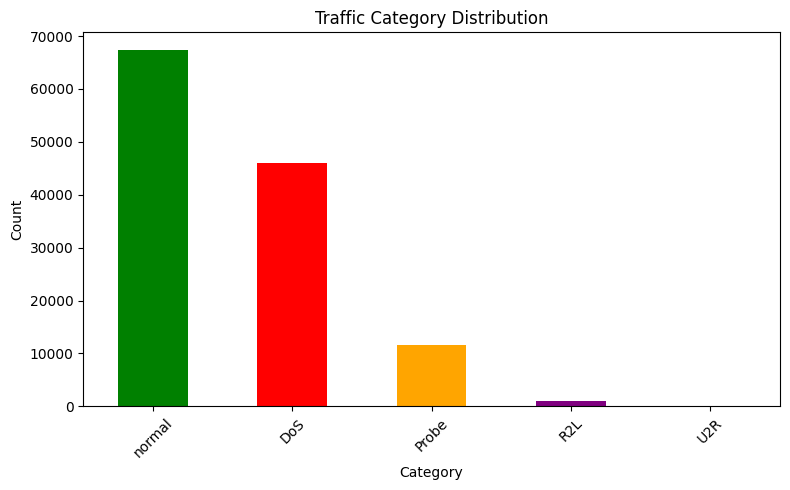

In [ ]:
plt.figure(figsize=(8,5))
train_df['attack_category'].value_counts().plot(kind='bar', color=['green','red','orange','purple','blue'])
plt.title('Traffic Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(train_df.isnull().sum().sum())

0


In [ ]:
print("Protocol types:", train_df['protocol_type'].unique())
print("Services:", train_df['service'].nunique(), "unique values")
print("Flags:", train_df['flag'].unique())

Protocol types: ['tcp' 'udp' 'icmp']
Services: 70 unique values
Flags: ['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']


In [ ]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


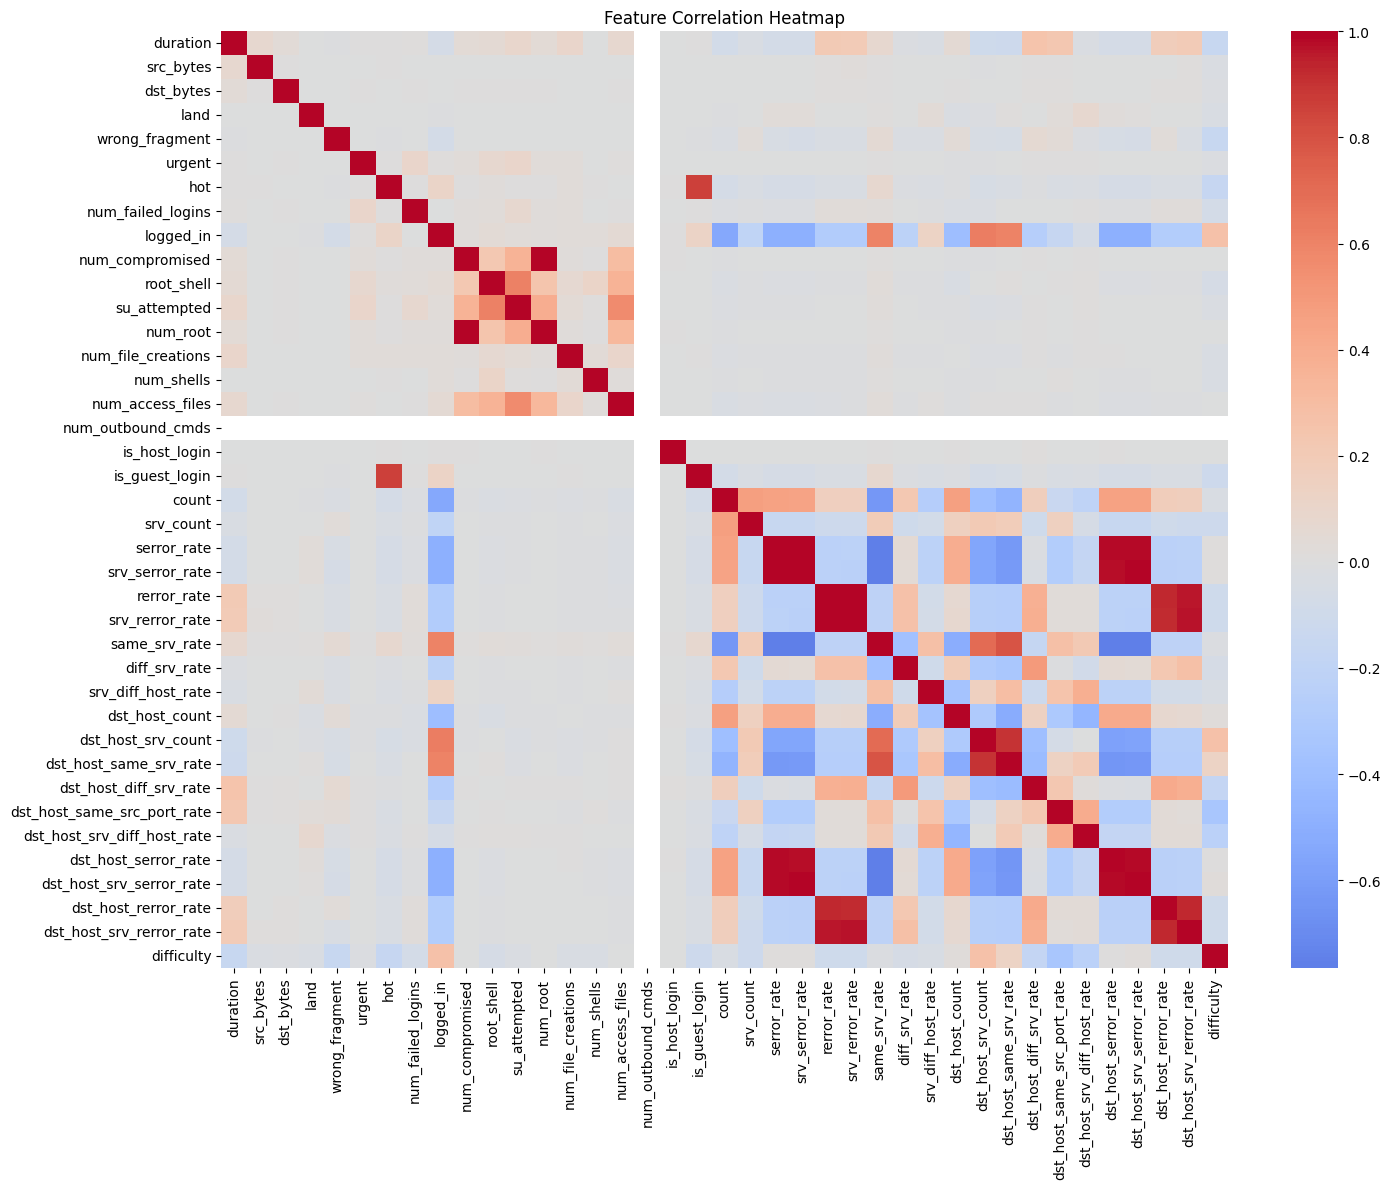

In [ ]:
plt.figure(figsize=(15,12))
numeric_df = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# 'difficulty' column is not a network feature, drop it
train_df = train_df.drop(columns=['difficulty', 'label'])
test_df = test_df.drop(columns=['difficulty', 'label'])

In [ ]:
# Encode protocol_type, service, flag using LabelEncoder
categorical_cols = ['protocol_type', 'service', 'flag']
encoder = LabelEncoder()

for col in categorical_cols:
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.transform(test_df[col])

print("Encoding done!")

Encoding done!


In [ ]:
# Encode attack categories as numbers
label_encoder = LabelEncoder()
train_df['attack_category'] = label_encoder.fit_transform(train_df['attack_category'])
test_df['attack_category'] = label_encoder.transform(test_df['attack_category'])

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label mapping: {'DoS': np.int64(0), 'Probe': np.int64(1), 'R2L': np.int64(2), 'U2R': np.int64(3), 'normal': np.int64(4)}


In [ ]:
X_train = train_df.drop(columns=['attack_category'])
y_train = train_df['attack_category']

X_test = test_df.drop(columns=['attack_category'])
y_test = test_df['attack_category']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (125973, 41)
X_test shape: (22544, 41)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE:", dict(zip(*np.unique(y_train_balanced, return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(45927), np.int64(1): np.int64(11656), np.int64(2): np.int64(995), np.int64(3): np.int64(52), np.int64(4): np.int64(67343)}
After SMOTE: {np.int64(0): np.int64(67343), np.int64(1): np.int64(67343), np.int64(2): np.int64(67343), np.int64(3): np.int64(67343), np.int64(4): np.int64(67343)}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training started...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1  # uses all CPU cores
)

rf_model.fit(X_train_balanced, y_train_balanced)

end = time.time()
print(f"Training done in {round(end - start, 2)} seconds")

Training started...
Training done in 66.07 seconds


In [ ]:
y_pred = rf_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         DoS       0.96      0.77      0.85      7458
       Probe       0.85      0.71      0.77      2421
         R2L       0.92      0.02      0.04      2885
         U2R       0.46      0.09      0.15        69
      normal       0.65      0.97      0.78      9711

    accuracy                           0.75     22544
   macro avg       0.77      0.51      0.52     22544
weighted avg       0.81      0.75      0.71     22544



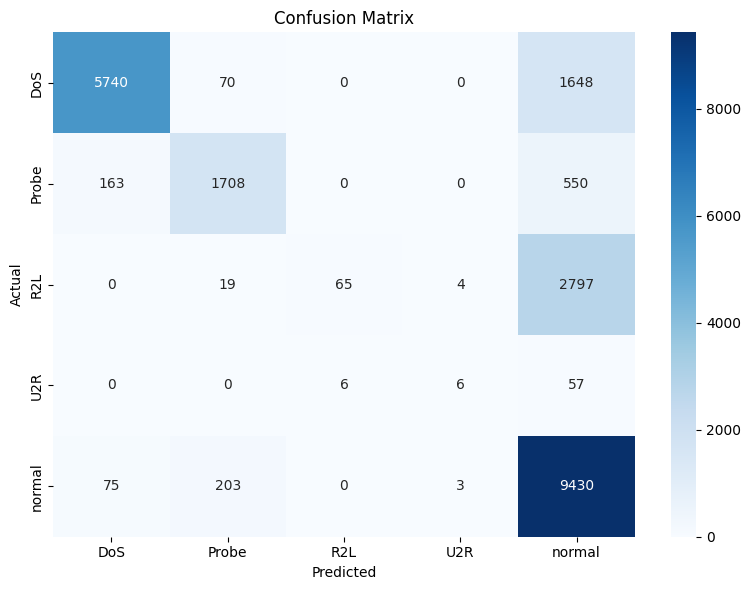

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

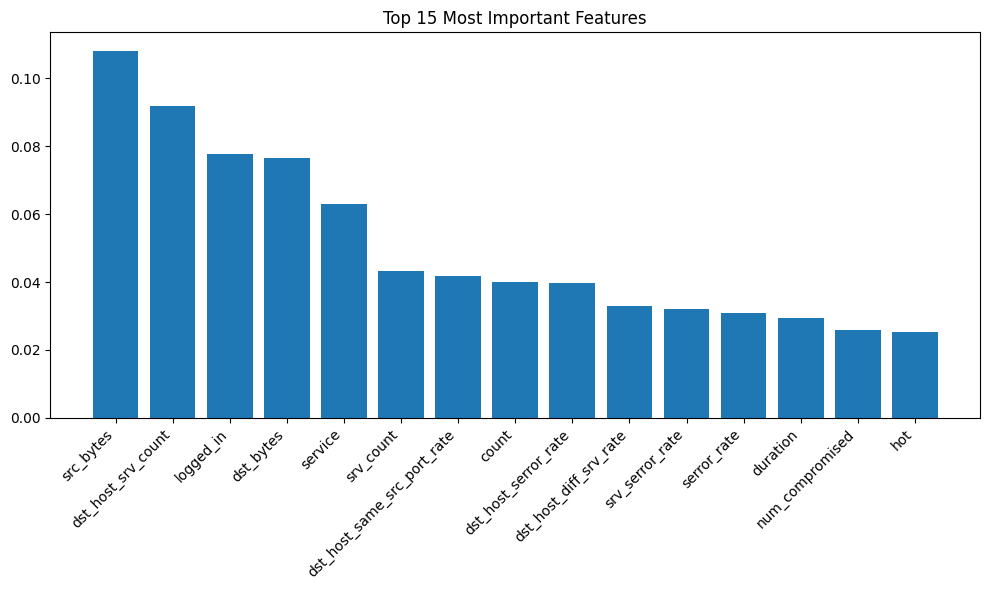

In [ ]:
feature_names = ['duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate']

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(10,6))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

os.makedirs('model_artifacts', exist_ok=True)

# Save model, scaler, and label encoder
joblib.dump(rf_model, 'model_artifacts/rf_model.pkl')
joblib.dump(scaler, 'model_artifacts/scaler.pkl')
joblib.dump(label_encoder, 'model_artifacts/label_encoder.pkl')

print("All artifacts saved!")

All artifacts saved!


In [ ]:
from google.colab import userdata
import boto3

aws_access_key = userdata.get('AWS_ACCESS_KEY')
aws_secret_key = userdata.get('AWS_SECRET_KEY')

s3 = boto3.client(
    's3',
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    region_name='us-east-1'
)

bucket_name = 'darshan-ids-project'  # replace with your actual bucket name

for filename in ['rf_model.pkl', 'scaler.pkl', 'label_encoder.pkl']:
    s3.upload_file(
        f'model_artifacts/{filename}',
        bucket_name,
        f'models/{filename}'
    )
    print(f"Uploaded: {filename}")

print("All artifacts uploaded to S3!")

Uploaded: rf_model.pkl
Uploaded: scaler.pkl
Uploaded: label_encoder.pkl
All artifacts uploaded to S3!


In [ ]:
response = s3.list_objects_v2(Bucket=bucket_name, Prefix='models/')
for obj in response['Contents']:
    print(obj['Key'], '→', obj['Size'], 'bytes')

models/label_encoder.pkl → 508 bytes
models/rf_model.pkl → 16665569 bytes
models/scaler.pkl → 2527 bytes


In [ ]:
lambda_code = '''
import json
import boto3
import joblib
import numpy as np
import os
import tempfile

# Load artifacts from S3 when Lambda starts
s3 = boto3.client('s3')
BUCKET = os.environ['BUCKET_NAME']

def load_artifact(filename):
    tmp_path = os.path.join(tempfile.gettempdir(), filename)
    s3.download_file(BUCKET, f'models/{filename}', tmp_path)
    return joblib.load(tmp_path)

# Load once at startup (not on every request)
model = load_artifact('rf_model.pkl')
scaler = load_artifact('scaler.pkl')
label_encoder = load_artifact('label_encoder.pkl')

def lambda_handler(event, context):
    try:
        body = json.loads(event['body'])
        features = np.array(body['features']).reshape(1, -1)
        features_scaled = scaler.transform(features)
        prediction = model.predict(features_scaled)
        category = label_encoder.inverse_transform(prediction)[0]
        confidence = round(float(model.predict_proba(features_scaled).max()), 4)

        return {
            'statusCode': 200,
            'body': json.dumps({
                'prediction': category,
                'confidence': confidence,
                'alert': category != 'normal'
            })
        }
    except Exception as e:
        return {
            'statusCode': 400,
            'body': json.dumps({'error': str(e)})
        }
'''

with open('lambda_function.py', 'w') as f:
    f.write(lambda_code)

print("Lambda function written!")

Lambda function written!


In [ ]:
!pip install --platform manylinux2014_x86_64 \
    --target ./package \
    --implementation cp \
    --python-version 3.12 \
    --only-binary=:all: \
    scikit-learn numpy joblib

print("Dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 9.7 MB/s eta 0:00:00


Dependencies installed!


In [ ]:
import shutil
import os

# Copy lambda function into package folder
shutil.copy('lambda_function.py', 'package/lambda_function.py')

# Zip it
shutil.make_archive('lambda_deployment', 'zip', 'package')

size = os.path.getsize('lambda_deployment.zip') / (1024*1024)
print(f"Zip created: {round(size, 2)} MB")

Zip created: 77.01 MB


In [ ]:
s3.upload_file(
    'lambda_deployment.zip',
    bucket_name,
    'lambda/lambda_deployment.zip'
)
print("Lambda zip uploaded to S3!")

Lambda zip uploaded to S3!


In [ ]:
import requests

API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"

# Test 1 — Normal traffic
test_normal = {
    "features": [0, 1, 2, 0, 491, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 1, 0, 0, 150, 25, 0.17, 0.03, 0.17, 0, 0.05, 0, 0, 0]
}

# Test 2 — DoS attack traffic
test_dos = {
    "features": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 511, 511, 1, 1, 0, 0, 1, 0, 0, 255, 255, 1, 0, 1, 0, 1, 1, 0, 0]
}

response1 = requests.post(API_URL, json=test_normal)
response2 = requests.post(API_URL, json=test_dos)

print("Normal traffic result:", response1.json())
print("DoS attack result:", response2.json())

Normal traffic result: {'prediction': 'normal', 'confidence': 0.9241, 'alert': False}
DoS attack result: {'prediction': 'DoS', 'confidence': 0.5433, 'alert': True}


In [ ]:
lambda_code = '''
import json
import boto3
import joblib
import numpy as np
import os
import tempfile

s3 = boto3.client('s3')
sns = boto3.client('sns', region_name='us-east-1')

BUCKET = os.environ['BUCKET_NAME']
SNS_ARN = os.environ['SNS_ARN']

def load_artifact(filename):
    tmp_path = os.path.join(tempfile.gettempdir(), filename)
    s3.download_file(BUCKET, f'models/{filename}', tmp_path)
    return joblib.load(tmp_path)

model = load_artifact('rf_model.pkl')
scaler = load_artifact('scaler.pkl')
label_encoder = load_artifact('label_encoder.pkl')

def lambda_handler(event, context):
    try:
        body = json.loads(event['body'])
        features = np.array(body['features']).reshape(1, -1)
        features_scaled = scaler.transform(features)
        prediction = model.predict(features_scaled)
        category = label_encoder.inverse_transform(prediction)[0]
        confidence = round(float(model.predict_proba(features_scaled).max()), 4)
        is_alert = category != 'normal'

        if is_alert:
            message = "INTRUSION DETECTED" + "\\n"
            message += "Attack Type: " + category + "\\n"
            message += "Confidence: " + str(confidence) + "\\n"
            message += "Immediate action may be required."

            sns.publish(
                TopicArn=SNS_ARN,
                Subject="IDS ALERT: " + category + " Attack Detected!",
                Message=message
            )

        return {
            'statusCode': 200,
            'body': json.dumps({
                'prediction': category,
                'confidence': confidence,
                'alert': is_alert
            })
        }
    except Exception as e:
        return {
            'statusCode': 400,
            'body': json.dumps({'error': str(e)})
        }
'''

with open('lambda_function.py', 'w') as f:
    f.write(lambda_code)

print("Updated Lambda code written!")

Updated Lambda code written!


In [ ]:
import shutil
import os

# Rebuild slim zip with updated function
os.makedirs('slim_package', exist_ok=True)
shutil.copy('lambda_function.py', 'slim_package/lambda_function.py')

import zipfile
with zipfile.ZipFile('lambda_slim.zip', 'w') as zipf:
    zipf.write('slim_package/lambda_function.py', 'lambda_function.py')

s3.upload_file('lambda_slim.zip', bucket_name, 'lambda/lambda_slim.zip')
print("Uploaded!")

Uploaded!


In [ ]:
import boto3
from google.colab import userdata

# Create Lambda client
lambda_client = boto3.client(
    'lambda',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

# Read the zip file
with open('lambda_slim.zip', 'rb') as f:
    zip_bytes = f.read()

# Update Lambda function code directly
response = lambda_client.update_function_code(
    FunctionName='ids-inference',
    ZipFile=zip_bytes
)

print("Lambda updated successfully!")
print("Status:", response['LastUpdateStatus'])

Lambda updated successfully!
Status: InProgress


In [ ]:
# Verify Lambda client works
response = lambda_client.get_function(FunctionName='ids-inference')
print("Function found:", response['Configuration']['FunctionName'])

Function found: ids-inference


In [ ]:
with open('lambda_slim.zip', 'rb') as f:
    zip_bytes = f.read()

response = lambda_client.update_function_code(
    FunctionName='ids-inference',
    ZipFile=zip_bytes
)

print("Lambda updated!")
print("Status:", response['LastUpdateStatus'])

Lambda updated!
Status: InProgress


In [ ]:
# Replace with your actual SNS ARN
SNS_ARN = "arn:aws:sns:us-east-1:119033255485:ids-alerts"

response = lambda_client.update_function_configuration(
    FunctionName='ids-inference',
    Environment={
        'Variables': {
            'BUCKET_NAME': bucket_name,
            'SNS_ARN': SNS_ARN
        }
    },
    Timeout=60,
    MemorySize=512
)

print("Configuration updated!")
print("Status:", response['LastUpdateStatus'])

Configuration updated!
Status: InProgress


In [ ]:
import requests

API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"

test_dos = {
    "features": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 511, 511, 1, 1, 0, 0, 1, 0, 0, 255, 255, 1, 0, 1, 0, 1, 1, 0, 0]
}

response = requests.post(API_URL, json=test_dos)
print("Result:", response.json())

Result: {'message': 'Internal Server Error'}


In [ ]:
import boto3
from google.colab import userdata

logs_client = boto3.client(
    'logs',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

# Get latest log stream
log_group = '/aws/lambda/ids-inference'
streams = logs_client.describe_log_streams(
    logGroupName=log_group,
    orderBy='LastEventTime',
    descending=True,
    limit=1
)

stream_name = streams['logStreams'][0]['logStreamName']

# Get log events
events = logs_client.get_log_events(
    logGroupName=log_group,
    logStreamName=stream_name,
    limit=20
)

print("=== LAMBDA LOGS ===")
for event in events['events']:
    print(event['message'])


=== LAMBDA LOGS ===
INIT_START Runtime Version: python:3.12.mainlinev2.v31	Runtime Version ARN: arn:aws:lambda:us-east-1::runtime:c1ab740f3656a72d7917665a940f8634df245489445f5a660de5a634d06c5433

[WARNING]	2026-09-06T12:42:32.318Z		LAMBDA_WARNING: Unhandled exception. The most likely cause is an issue in the function code. However, in rare cases, a Lambda runtime update can cause unexpected function behavior. For functions using managed runtimes, runtime updates can be triggered by a function change, or can be applied automatically. To determine if the runtime has been updated, check the runtime version in the INIT_START log entry. If this error correlates with a change in the runtime version, you may be able to mitigate this error by temporarily rolling back to the previous runtime version. For more information, see https://docs.aws.amazon.com/lambda/latest/dg/runtimes-update.html

[ERROR] Runtime.ImportModuleError: Unable to import module 'lambda_function': No module named 'joblib'
T

In [ ]:
import subprocess
import os
import shutil

# Create layer folder structure
os.makedirs('layer/python', exist_ok=True)

# Install packages into layer folder
subprocess.run([
    'pip', 'install',
    '--platform', 'manylinux2014_x86_64',
    '--target', 'layer/python',
    '--implementation', 'cp',
    '--python-version', '3.12',
    '--only-binary=:all:',
    'scikit-learn', 'numpy', 'joblib'
], check=True)

print("Packages installed!")

Packages installed!


In [ ]:
shutil.make_archive('lambda_layer', 'zip', 'layer')
size = os.path.getsize('lambda_layer.zip') / (1024*1024)
print(f"Layer zip size: {round(size, 2)} MB")

Layer zip size: 77.09 MB


In [ ]:
response = lambda_client.publish_layer_version(
    LayerName='ids-dependencies',
    Description='scikit-learn, numpy, joblib for IDS',
    Content={
        'S3Bucket': bucket_name,
        'S3Key': 'lambda/lambda_layer.zip'
    },
    CompatibleRuntimes=['python3.12'],
    CompatibleArchitectures=['x86_64']
)

layer_arn = response['LayerVersionArn']
print("Layer ARN:", layer_arn)

InvalidParameterValueException: An error occurred (InvalidParameterValueException) when calling the PublishLayerVersion operation: Error occurred while GetObject. S3 Error Code: NoSuchKey. S3 Error Message: The specified key does not exist.

In [ ]:
print("Bucket name:", bucket_name)


Bucket name: darshan-ids-project


In [ ]:
import os
size = os.path.getsize('lambda_layer.zip') / (1024*1024)
print(f"Layer zip exists: {round(size, 2)} MB")

Layer zip exists: 77.09 MB


In [ ]:
from google.colab import userdata

# Recreate S3 client to make sure it's fresh
s3 = boto3.client(
    's3',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

BUCKET = 'darshan-ids-project'  # hardcode it here

# Upload layer
s3.upload_file('lambda_layer.zip', BUCKET, 'lambda/lambda_layer.zip')
print("Uploaded!")

# Verify it's there
response = s3.list_objects_v2(Bucket=BUCKET, Prefix='lambda/')
for obj in response['Contents']:
    print(obj['Key'], '→', round(obj['Size']/1024/1024, 2), 'MB')

Uploaded!
lambda/lambda_deployment.zip → 77.01 MB
lambda/lambda_layer.zip → 77.09 MB
lambda/lambda_slim.zip → 0.0 MB


In [ ]:
response = lambda_client.publish_layer_version(
    LayerName='ids-dependencies',
    Description='scikit-learn, numpy, joblib for IDS',
    Content={
        'S3Bucket': BUCKET,
        'S3Key': 'lambda/lambda_layer.zip'
    },
    CompatibleRuntimes=['python3.12'],
    CompatibleArchitectures=['x86_64']
)

layer_arn = response['LayerVersionArn']
print("Layer ARN:", layer_arn)

Layer ARN: arn:aws:lambda:us-east-1:119033255485:layer:ids-dependencies:1


In [ ]:
print("Bucket name:", bucket_name)

Bucket name: darshan-ids-project


In [ ]:
import os
size = os.path.getsize('lambda_layer.zip') / (1024*1024)
print(f"Layer zip exists: {round(size, 2)} MB")

Layer zip exists: 77.09 MB


In [ ]:
s3.upload_file('lambda_layer.zip', 'darshan-ids-project', 'lambda/lambda_layer.zip')
print("Uploaded!")

# Verify
response = s3.list_objects_v2(Bucket='darshan-ids-project', Prefix='lambda/')
for obj in response['Contents']:
    print(obj['Key'], '→', round(obj['Size']/1024/1024, 2), 'MB')

Uploaded!
lambda/lambda_deployment.zip → 77.01 MB
lambda/lambda_layer.zip → 77.09 MB
lambda/lambda_slim.zip → 0.0 MB


In [ ]:
response = lambda_client.publish_layer_version(
    LayerName='ids-dependencies',
    Description='scikit-learn, numpy, joblib for IDS',
    Content={
        'S3Bucket': 'darshan-ids-project',
        'S3Key': 'lambda/lambda_layer.zip'
    },
    CompatibleRuntimes=['python3.12'],
    CompatibleArchitectures=['x86_64']
)

layer_arn = response['LayerVersionArn']
print("Layer ARN:", layer_arn)

Layer ARN: arn:aws:lambda:us-east-1:119033255485:layer:ids-dependencies:2


In [ ]:
response = lambda_client.update_function_configuration(
    FunctionName='ids-inference',
    Layers=[layer_arn],
    Environment={
        'Variables': {
            'BUCKET_NAME': 'darshan-ids-project',
            'SNS_ARN': 'arn:aws:sns:us-east-1:119033255485:ids-alerts'
        }
    },
    Timeout=60,
    MemorySize=512
)

print("Layer attached!")
print("Status:", response['LastUpdateStatus'])

Layer attached!
Status: InProgress


In [ ]:
import requests
import time

print("Waiting 10 seconds for Lambda to update...")
time.sleep(10)

API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"

test_dos = {
    "features": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 511, 511, 1, 1, 0, 0, 1, 0, 0, 255, 255, 1, 0, 1, 0, 1, 1, 0, 0]
}

response = requests.post(API_URL, json=test_dos)
print("Result:", response.json())

Waiting 10 seconds for Lambda to update...
Result: {'error': 'An error occurred (AuthorizationError) when calling the Publish operation: User: arn:aws:sts::119033255485:assumed-role/ids-inference-role-a3wwpfye/ids-inference is not authorized to perform: SNS:Publish on resource: arn:aws:sns:us-east-1:119033255485:ids-alerts because no identity-based policy allows the SNS:Publish action'}


In [ ]:
import boto3
from google.colab import userdata

iam_client = boto3.client(
    'iam',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

# Attach SNS policy to Lambda execution role
iam_client.attach_role_policy(
    RoleName='ids-inference-role-a3wwpfye',
    PolicyArn='arn:aws:iam::aws:policy/AmazonSNSFullAccess'
)

print("SNS permission added to Lambda role!")

SNS permission added to Lambda role!


In [ ]:
import requests
import time

print("Waiting 10 seconds for Lambda to update...")
time.sleep(10)

API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"

test_dos = {
    "features": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 511, 511, 1, 1, 0, 0, 1, 0, 0, 255, 255, 1, 0, 1, 0, 1, 1, 0, 0]
}

response = requests.post(API_URL, json=test_dos)
print("Result:", response.json())

Waiting 10 seconds for Lambda to update...
Result: {'prediction': 'DoS', 'confidence': 0.5433, 'alert': True}


In [ ]:
sns_client = boto3.client(
    'sns',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

response = sns_client.list_subscriptions_by_topic(
    TopicArn='arn:aws:sns:us-east-1:119033255485:ids-alerts'
)

for sub in response['Subscriptions']:
    print("Email:", sub['Endpoint'])
    print("Status:", sub['SubscriptionArn'])

Email: darshandarsha439@gmail.com
Status: arn:aws:sns:us-east-1:119033255485:ids-alerts:711f7a9e-237a-424d-92b0-38cd70bee5c6


In [ ]:
from google.colab import files

files.download('model_artifacts/rf_model.pkl')
files.download('model_artifacts/scaler.pkl')
files.download('model_artifacts/label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Block 1 — Imports
import pandas as pd
import numpy as np
import boto3
import requests
from google.colab import userdata

# Block 2 — Restore variables
bucket_name = 'darshan-ids-project'
API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"  # paste your actual URL

# Block 3 — Test API is still alive
test = {"features": [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,1,1,0,0,1,0,0,255,255,1,0,1,0,1,1,0,0]}
response = requests.post(API_URL, json=test)
print("API Status:", response.json())

ModuleNotFoundError: No module named 'boto3'

In [ ]:
!pip install boto3 requests pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.7 MB/s eta 0:00:00


In [ ]:
# Block 1 — Imports
import pandas as pd
import numpy as np
import boto3
import requests
from google.colab import userdata

# Block 2 — Restore variables
bucket_name = 'darshan-ids-project'
API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"  # paste your actual URL

# Block 3 — Test API is still alive
test = {"features": [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,1,1,0,0,1,0,0,255,255,1,0,1,0,1,1,0,0]}
response = requests.post(API_URL, json=test)
print("API Status:", response.json())

API Status: {'prediction': 'DoS', 'confidence': 0.5433, 'alert': True}


In [ ]:
import time
import random

API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"

# 20 mixed traffic records — normal + all attack types
traffic_records = {
    "normal":  [0,1,2,0,491,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,1,0,0,150,25,0.17,0.03,0.17,0,0.05,0,0,0],
    "DoS":     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,1,1,0,0,1,0,0,255,255,1,0,1,0,1,1,0,0],
    "Probe":   [0,2,52,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,229,229,1,0,0,0,0,0,0,0],
    "R2L":     [0,0,21,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,24,9,0.38,0,0.38,0,0,0,0,0],
    "U2R":     [0,0,21,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,1,0,1,0,0,0,0,0],
}

# Simulate 20 traffic records
sequence = ["normal","normal","DoS","normal","Probe","normal","DoS","R2L",
            "normal","U2R","normal","DoS","normal","Probe","normal",
            "DoS","normal","R2L","normal","DoS"]

print("=" * 60)
print("  CloudGuard IDS — Live Traffic Simulation")
print("=" * 60)

results = []
for i, traffic_type in enumerate(sequence):
    features = traffic_records[traffic_type]
    response = requests.post(API_URL, json={"features": features})
    result = response.json()

    prediction = result.get('prediction', 'error')
    confidence = result.get('confidence', 0)
    alert = result.get('alert', False)

    status = "🚨 ALERT" if alert else "✅ SAFE"
    correct = "✓" if prediction == traffic_type else "✗"

    print(f"[{i+1:02d}] Sent: {traffic_type:<8} → Predicted: {prediction:<8} | Confidence: {confidence:.2f} | {status} {correct}")
    results.append({
        'sent': traffic_type,
        'predicted': prediction,
        'confidence': confidence,
        'alert': alert
    })
    time.sleep(1)

print("=" * 60)
attacks_detected = sum(1 for r in results if r['alert'])
print(f"  Total records: {len(results)}")
print(f"  Attacks detected: {attacks_detected}")
print(f"  Safe traffic: {len(results) - attacks_detected}")
print("=" * 60)

  CloudGuard IDS — Live Traffic Simulation
[01] Sent: normal   → Predicted: normal   | Confidence: 0.92 | ✅ SAFE ✓
[02] Sent: normal   → Predicted: normal   | Confidence: 0.92 | ✅ SAFE ✓
[03] Sent: DoS      → Predicted: DoS      | Confidence: 0.54 | 🚨 ALERT ✓
[04] Sent: normal   → Predicted: normal   | Confidence: 0.92 | ✅ SAFE ✓
[05] Sent: Probe    → Predicted: normal   | Confidence: 0.76 | ✅ SAFE ✗
[06] Sent: normal   → Predicted: normal   | Confidence: 0.92 | ✅ SAFE ✓
[07] Sent: DoS      → Predicted: DoS      | Confidence: 0.54 | 🚨 ALERT ✓
[08] Sent: R2L      → Predicted: normal   | Confidence: 0.51 | ✅ SAFE ✗
[09] Sent: normal   → Predicted: normal   | Confidence: 0.92 | ✅ SAFE ✓
[10] Sent: U2R      → Predicted: normal   | Confidence: 0.36 | ✅ SAFE ✗
[11] Sent: normal   → Predicted: normal   | Confidence: 0.92 | ✅ SAFE ✓
[12] Sent: DoS      → Predicted: DoS      | Confidence: 0.54 | 🚨 ALERT ✓
[13] Sent: normal   → Predicted: normal   | Confidence: 0.92 | ✅ SAFE ✓
[14] Sent: Probe  

In [ ]:
!pip install streamlit pyngrok -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 27.1 MB/s eta 0:00:00


In [ ]:
lines = [
    "import streamlit as st",
    "import requests",
    "import time",
    "import pandas as pd",
    "from datetime import datetime",
    "",
    f'API_URL = "{API_URL}"',
    "",
    "traffic_records = {",
    '    "normal":  [0,1,2,0,491,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,1,0,0,150,25,0.17,0.03,0.17,0,0.05,0,0,0],',
    '    "DoS":     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,1,1,0,0,1,0,0,255,255,1,0,1,0,1,1,0,0],',
    '    "Probe":   [0,2,52,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,229,229,1,0,0,0,0,0,0,0],',
    '    "R2L":     [0,0,21,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,24,9,0.38,0,0.38,0,0,0,0,0],',
    '    "U2R":     [0,0,21,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,1,0,1,0,0,0,0,0],',
    "}",
    "",
    "st.set_page_config(page_title='CloudGuard IDS', page_icon='🛡️', layout='wide')",
    "",
    "if 'log' not in st.session_state: st.session_state.log = []",
    "if 'total' not in st.session_state: st.session_state.total = 0",
    "if 'alerts' not in st.session_state: st.session_state.alerts = 0",
    "if 'last_result' not in st.session_state: st.session_state.last_result = None",
    "",
    "st.markdown('<h1 style=text-align:center>🛡️ CloudGuard IDS</h1>', unsafe_allow_html=True)",
    "st.markdown('<p style=text-align:center;color:#888>Cloud-Based Intrusion Detection | AWS Lambda + ML</p>', unsafe_allow_html=True)",
    "st.divider()",
    "",
    "col1, col2 = st.columns([1, 2])",
    "",
    "def send_traffic(traffic_type):",
"    response = requests.post(API_URL, json={'features': traffic_records[traffic_type]})",
"    result = response.json()",
"    result['sent'] = traffic_type",
"    result['time'] = datetime.now().strftime('%H:%M:%S')",
"    # Low confidence on normal = suspicious traffic",
"    if result['prediction'] == 'normal' and result['confidence'] < 0.60:",
"        result['alert'] = True",
"        result['prediction'] = 'Suspicious'",
"    st.session_state.last_result = result",
"    st.session_state.log.insert(0, result)",
"    st.session_state.total += 1",
"    if result['alert']: st.session_state.alerts += 1",
    "",
    "with col1:",
    "    st.markdown('### 🎮 Send Traffic')",
    "    if st.button('✅ Normal Traffic', use_container_width=True): send_traffic('normal')",
    "    if st.button('💥 DoS Attack', use_container_width=True): send_traffic('DoS')",
    "    if st.button('🔍 Probe Attack', use_container_width=True): send_traffic('Probe')",
    "    if st.button('🔓 R2L Attack', use_container_width=True): send_traffic('R2L')",
    "    if st.button('☠️ U2R Attack', use_container_width=True): send_traffic('U2R')",
    "    if st.button('🔄 Auto Simulate 20 Records', use_container_width=True):",
    "        sequence = ['normal','DoS','normal','Probe','DoS','normal','R2L','DoS','normal','U2R','DoS','normal','DoS','normal','Probe','DoS','normal','R2L','normal','DoS']",
    "        p = st.progress(0)",
    "        for i,t in enumerate(sequence):",
    "            send_traffic(t)",
    "            p.progress((i+1)/len(sequence))",
    "            time.sleep(0.5)",
    "        st.rerun()",
    "",
    "with col2:",
    "    if st.session_state.last_result:",
    "        r = st.session_state.last_result",
    "        if r['alert']:",
    "            st.error(f'🚨 ATTACK DETECTED: {r[\"prediction\"]} | Confidence: {r[\"confidence\"]*100:.1f}% | Email Alert Sent via SNS')",
    "        else:",
    "            st.success(f'✅ NORMAL TRAFFIC | Confidence: {r[\"confidence\"]*100:.1f}% | No threat detected')",
    "    else:",
    "        st.info('Click a button to send traffic to the IDS')",
    "    st.divider()",
    "    m1,m2,m3 = st.columns(3)",
    "    m1.metric('Total Records', st.session_state.total)",
    "    m2.metric('Attacks Detected', st.session_state.alerts)",
    "    m3.metric('Safe Traffic', st.session_state.total - st.session_state.alerts)",
    "    if st.session_state.log:",
    "        st.markdown('### 📋 Traffic Log')",
    "        df = pd.DataFrame(st.session_state.log[:15])[['time','sent','prediction','confidence','alert']]",
    "        df.columns = ['Time','Sent','Predicted','Confidence','Alert']",
    "        df['Alert'] = df['Alert'].map({True:'🚨 YES', False:'✅ NO'})",
    "        df['Confidence'] = df['Confidence'].apply(lambda x: f'{x*100:.1f}%')",
    "        st.dataframe(df, use_container_width=True, hide_index=True)",
    "    if st.button('🗑️ Clear Log'):",
    "        st.session_state.log=[]",
    "        st.session_state.total=0",
    "        st.session_state.alerts=0",
    "        st.session_state.last_result=None",
    "        st.rerun()",
]

with open('dashboard.py', 'w') as f:
    f.write('\n'.join(lines))

print("Dashboard written!")

Dashboard written!


In [ ]:
from pyngrok import ngrok
import subprocess
import time

# Replace with your actual API URL in dashboard.py
with open('dashboard.py', 'r') as f:
    content = f.read()
content = content.replace('https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference', API_URL)
with open('dashboard.py', 'w') as f:
    f.write(content)

# Start Streamlit
proc = subprocess.Popen(['streamlit', 'run', 'dashboard.py',
                         '--server.port', '8501',
                         '--server.headless', 'true'])
time.sleep(4)

# Get public URL
# Authenticate ngrok with your token
# Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok auth token
# You can get it from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3JMtoXh9FmxuokdR6FiwV0rlFzu_2BTxMkdVeezA5y7iWMmqR')

public_url = ngrok.connect(8501)
print("=" * 50)
print("🚀 Dashboard live at:")
print(public_url)
print("=" * 50)
print("Open that URL in your browser!")

FileNotFoundError: [Errno 2] No such file or directory: 'dashboard.py'

In [ ]:
if 'proc' in locals() and proc.poll() is None:
    proc.terminate()
    print("Streamlit process terminated.")

if ngrok.get_tunnels():
    ngrok.kill()
    print("Ngrok tunnels killed.")


Ngrok tunnels killed.


In [ ]:
!pip install streamlit pyngrok -q

In [ ]:
sns_client = boto3.client(
    'sns',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

# Unsubscribe old email
sns_client.unsubscribe(
    SubscriptionArn='arn:aws:sns:us-east-1:119033255485:ids-alerts:711f7a9e-237a-424d-92b0-38cd70bee5c6'
)
print("Old email removed!")

# Subscribe new email
sns_client.subscribe(
    TopicArn='arn:aws:sns:us-east-1:119033255485:ids-alerts',
    Protocol='email',
    Endpoint='carry3778@gmail.com'  # replace this
)
print("New email subscribed — check inbox and click confirmation link!")

Old email removed!
New email subscribed — check inbox and click confirmation link!


In [ ]:
# Run this to stop Streamlit + ngrok cleanly
proc.terminate()
ngrok.kill()
print("Dashboard stopped!")

Dashboard stopped!


In [ ]:
# Run once now to save ngrok auth
!ngrok authtoken 3JMtoXh9FmxuokdR6FiwV0rlFzu_2BTxMkdVeezA5y7iWMmqR

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from google.colab import files
files.download('dashboard.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install boto3 requests pandas numpy streamlit pyngrok imbalanced-learn scikit-learn -q

# Step 2 — Imports
import pandas as pd
import numpy as np
import boto3
import requests
import time
import joblib
from datetime import datetime
from google.colab import userdata

# Step 3 — Project variables
bucket_name = 'darshan-ids-project'
API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"
SNS_ARN = "arn:aws:sns:us-east-1:119033255485:ids-alerts"

# Step 4 — AWS clients
s3 = boto3.client(
    's3',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

lambda_client = boto3.client(
    'lambda',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

sns_client = boto3.client(
    'sns',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

logs_client = boto3.client(
    'logs',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

# Step 5 — Quick API health check
try:
    test = {"features": [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,1,1,0,0,1,0,0,255,255,1,0,1,0,1,1,0,0]}
    response = requests.post(API_URL, json=test)
    result = response.json()
    print("=" * 50)
    print("  ✅ CloudGuard IDS — Ready")
    print(f"  API: Online")
    print(f"  Test prediction: {result.get('prediction')} (confidence: {result.get('confidence')})")
    print(f"  Bucket: {bucket_name}")
    print("=" * 50)
except Exception as e:
    print("❌ API check failed:", e)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.0 MB/s eta 0:00:00
  ✅ CloudGuard IDS — Ready
  API: Online
  Test prediction: DoS (confidence: 0.5433)
  Bucket: darshan-ids-project


In [ ]:
from pyngrok import ngrok
import subprocess
import time

# Replace with your actual API URL in dashboard.py
with open('dashboard.py', 'r') as f:
    content = f.read()
content = content.replace('https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference', API_URL)
with open('dashboard.py', 'w') as f:
    f.write(content)

# Start Streamlit
proc = subprocess.Popen(['streamlit', 'run', 'dashboard.py',
                         '--server.port', '8501',
                         '--server.headless', 'true'])
time.sleep(4)

# Get public URL
# Authenticate ngrok with your token
# Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok auth token
# You can get it from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3JMtoXh9FmxuokdR6FiwV0rlFzu_2BTxMkdVeezA5y7iWMmqR')

public_url = ngrok.connect(8501)
print("=" * 50)
print("🚀 Dashboard live at:")
print(public_url)
print("=" * 50)
print("Open that URL in your browser!")

🚀 Dashboard live at:
NgrokTunnel: "https://headrest-reclining-earthy.ngrok-free.dev" -> "http://localhost:8501"
Open that URL in your browser!


In [ ]:
# Run this to stop Streamlit + ngrok cleanly
proc.terminate()
ngrok.kill()
print("Dashboard stopped!")


Dashboard stopped!


In [5]:
from pyngrok import ngrok
import subprocess
import time

# Replace with your actual API URL in dashboard.py
with open('dashboard.py', 'r') as f:
    content = f.read()
content = content.replace('https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference', API_URL)
with open('dashboard.py', 'w') as f:
    f.write(content)

# Start Streamlit
proc = subprocess.Popen(['streamlit', 'run', 'dashboard.py',
                         '--server.port', '8501',
                         '--server.headless', 'true'])
time.sleep(4)

# Get public URL
# Authenticate ngrok with your token
# Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok auth token
# You can get it from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3JMtoXh9FmxuokdR6FiwV0rlFzu_2BTxMkdVeezA5y7iWMmqR')

public_url = ngrok.connect(8501)
print("=" * 50)
print("🚀 Dashboard live at:")
print(public_url)
print("=" * 50)

🚀 Dashboard live at:
NgrokTunnel: "https://headrest-reclining-earthy.ngrok-free.dev" -> "http://localhost:8501"


In [2]:
!pip install boto3 requests pandas numpy streamlit pyngrok imbalanced-learn scikit-learn -q

# Step 2 — Imports
import pandas as pd
import numpy as np
import boto3
import requests
import time
import joblib
from datetime import datetime
from google.colab import userdata

# Step 3 — Project variables
bucket_name = 'darshan-ids-project'
API_URL = "https://hcgw43e08f.execute-api.us-east-1.amazonaws.com/default/ids-inference"
SNS_ARN = "arn:aws:sns:us-east-1:119033255485:ids-alerts"

# Step 4 — AWS clients
s3 = boto3.client(
    's3',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

lambda_client = boto3.client(
    'lambda',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

sns_client = boto3.client(
    'sns',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

logs_client = boto3.client(
    'logs',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY'),
    aws_secret_access_key=userdata.get('AWS_SECRET_KEY'),
    region_name='us-east-1'
)

# Step 5 — Quick API health check
try:
    test = {"features": [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,1,1,0,0,1,0,0,255,255,1,0,1,0,1,1,0,0]}
    response = requests.post(API_URL, json=test)
    result = response.json()
    print("=" * 50)
    print("  ✅ CloudGuard IDS — Ready")
    print(f"  API: Online")
    print(f"  Test prediction: {result.get('prediction')} (confidence: {result.get('confidence')})")
    print(f"  Bucket: {bucket_name}")
    print("=" * 50)
except Exception as e:
    print("❌ API check failed:", e)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.1 MB/s eta 0:00:00
  ✅ CloudGuard IDS — Ready
  API: Online
  Test prediction: DoS (confidence: 0.5433)
  Bucket: darshan-ids-project


In [4]:
lines = [
    "import streamlit as st",
    "import requests",
    "import time",
    "import pandas as pd",
    "from datetime import datetime",
    "",
    f'API_URL = "{API_URL}"',
    "",
    "traffic_records = {",
    '    "normal":  [0,1,2,0,491,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,1,0,0,150,25,0.17,0.03,0.17,0,0.05,0,0,0],',
    '    "DoS":     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,1,1,0,0,1,0,0,255,255,1,0,1,0,1,1,0,0],',
    '    "Probe":   [0,2,52,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,229,229,1,0,0,0,0,0,0,0],',
    '    "R2L":     [0,0,21,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,24,9,0.38,0,0.38,0,0,0,0,0],',
    '    "U2R":     [0,0,21,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,1,0,1,0,0,0,0,0],',
    "}",
    "",
    "st.set_page_config(page_title='CloudGuard IDS', page_icon='🛡️', layout='wide')",
    "",
    "if 'log' not in st.session_state: st.session_state.log = []",
    "if 'total' not in st.session_state: st.session_state.total = 0",
    "if 'alerts' not in st.session_state: st.session_state.alerts = 0",
    "if 'last_result' not in st.session_state: st.session_state.last_result = None",
    "",
    "st.markdown('<h1 style=text-align:center>🛡️ CloudGuard IDS</h1>', unsafe_allow_html=True)",
    "st.markdown('<p style=text-align:center;color:#888>Cloud-Based Intrusion Detection | AWS Lambda + ML</p>', unsafe_allow_html=True)",
    "st.divider()",
    "",
    "col1, col2 = st.columns([1, 2])",
    "",
    "def send_traffic(traffic_type):",
"    response = requests.post(API_URL, json={'features': traffic_records[traffic_type]})",
"    result = response.json()",
"    result['sent'] = traffic_type",
"    result['time'] = datetime.now().strftime('%H:%M:%S')",
"    # Low confidence on normal = suspicious traffic",
"    if result['prediction'] == 'normal' and result['confidence'] < 0.60:",
"        result['alert'] = True",
"        result['prediction'] = 'Suspicious'",
"    st.session_state.last_result = result",
"    st.session_state.log.insert(0, result)",
"    st.session_state.total += 1",
"    if result['alert']: st.session_state.alerts += 1",
    "",
    "with col1:",
    "    st.markdown('### 🎮 Send Traffic')",
    "    if st.button('✅ Normal Traffic', use_container_width=True): send_traffic('normal')",
    "    if st.button('💥 DoS Attack', use_container_width=True): send_traffic('DoS')",
    "    if st.button('🔍 Probe Attack', use_container_width=True): send_traffic('Probe')",
    "    if st.button('🔓 R2L Attack', use_container_width=True): send_traffic('R2L')",
    "    if st.button('☠️ U2R Attack', use_container_width=True): send_traffic('U2R')",
    "    if st.button('🔄 Auto Simulate 20 Records', use_container_width=True):",
    "        sequence = ['normal','DoS','normal','Probe','DoS','normal','R2L','DoS','normal','U2R','DoS','normal','DoS','normal','Probe','DoS','normal','R2L','normal','DoS']",
    "        p = st.progress(0)",
    "        for i,t in enumerate(sequence):",
    "            send_traffic(t)",
    "            p.progress((i+1)/len(sequence))",
    "            time.sleep(0.5)",
    "        st.rerun()",
    "",
    "with col2:",
    "    if st.session_state.last_result:",
    "        r = st.session_state.last_result",
    "        if r['alert']:",
    "            st.error(f'🚨 ATTACK DETECTED: {r[\"prediction\"]} | Confidence: {r[\"confidence\"]*100:.1f}% | Email Alert Sent via SNS')",
    "        else:",
    "            st.success(f'✅ NORMAL TRAFFIC | Confidence: {r[\"confidence\"]*100:.1f}% | No threat detected')",
    "    else:",
    "        st.info('Click a button to send traffic to the IDS')",
    "    st.divider()",
    "    m1,m2,m3 = st.columns(3)",
    "    m1.metric('Total Records', st.session_state.total)",
    "    m2.metric('Attacks Detected', st.session_state.alerts)",
    "    m3.metric('Safe Traffic', st.session_state.total - st.session_state.alerts)",
    "    if st.session_state.log:",
    "        st.markdown('### 📋 Traffic Log')",
    "        df = pd.DataFrame(st.session_state.log[:15])[['time','sent','prediction','confidence','alert']]",
    "        df.columns = ['Time','Sent','Predicted','Confidence','Alert']",
    "        df['Alert'] = df['Alert'].map({True:'🚨 YES', False:'✅ NO'})",
    "        df['Confidence'] = df['Confidence'].apply(lambda x: f'{x*100:.1f}%')",
    "        st.dataframe(df, use_container_width=True, hide_index=True)",
    "    if st.button('🗑️ Clear Log'):",
    "        st.session_state.log=[]",
    "        st.session_state.total=0",
    "        st.session_state.alerts=0",
    "        st.session_state.last_result=None",
    "        st.rerun()",
]

with open('dashboard.py', 'w') as f:
    f.write('\n'.join(lines))

print("Dashboard written!")

Dashboard written!


In [6]:
# Run this to stop Streamlit + ngrok cleanly
proc.terminate()
ngrok.kill()
print("Dashboard stopped!")

Dashboard stopped!
